# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


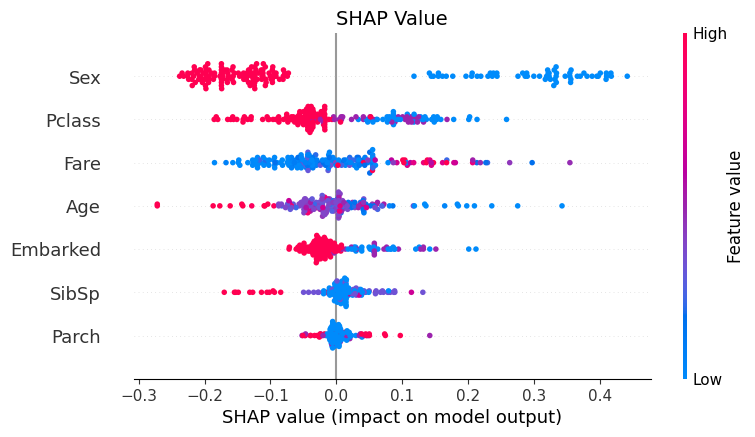

Stacking F1: 0.765625


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [1]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자 # 안배운 모델은 사용 x
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

X = df.drop('churn', axis=1) # churn를 제외하고 문제지로 설정
y = df['churn'] # y를 정답지로 설정

# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0500
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1370
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1340
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,0.9430
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1340
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0300
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.0930
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0090
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0080
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0100


In [6]:
# 필요한 도구들 import

import pandas as pd # pandas 사용
import numpy as np # numpy 사용

from sklearn.model_selection import train_test_split # train_test_split 사용
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier # RandomForestClassifier, GradientBoostingClassifier, StackingClassifier 사용
from sklearn.metrics import f1_score # f1_score 사용
from sklearn.preprocessing import LabelEncoder, StandardScaler # LabelEncoder, StandardScaler 사용

from sklearn.ensemble import RandomForestClassifier, StackingClassifier # RandomForestClassifier, StackingClassifier 사용
from xgboost import XGBClassifier # XGBClassifier 사용
from lightgbm import LGBMClassifier # LGBMClassifier 사용
from sklearn.linear_model import LogisticRegression # LogisticRegression 사용

import optuna # optuna 사용
import shap # shap 사용
import matplotlib.pyplot as plt # matplotlib.pyplot 사용
import seaborn as sns # seaborn 사용
import platform # platform 사용

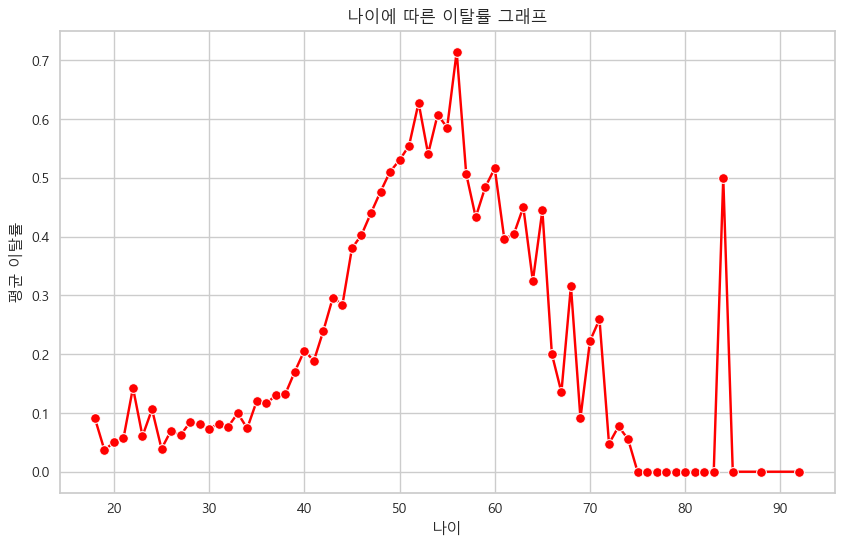

In [7]:
# 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv') # 'Bank Customer Churn Prediction.csv' 파일 불러오기

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

# 전처리
df = df.drop(columns=['customer_id'], errors='ignore') # 필요없는 컬럼 제거 / 고객 ID는 연관성이 없어서 제거

# 범주형 인코딩
le_country = LabelEncoder() # country 컬럼은 범주형이라 숫자형으로 변환
le_gender = LabelEncoder() # gender 컬럼은 범주형이라 숫자형으로 변환

df['country'] = le_country.fit_transform(df['country']) # country에 fit하고 변환
df['gender'] = le_gender.fit_transform(df['gender']) # gender에 fit하고 변환

# EDA
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 한글 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지

fig, ax = plt.subplots(figsize=(10, 6)) # 그래프 그리기

sns.lineplot(ax=ax, x='age', y='churn', data=df, color='red', marker='o', errorbar=None) # 꺽은선 그래프 그리기

# 제목과 축 이름을 Age에 맞게 변경합니다.
ax.set_title('나이에 따른 이탈률 그래프') # 제목
ax.set_ylabel('평균 이탈률') # y축 이름
ax.set_xlabel('나이') # x축 이름
plt.show() # 출력

X = df.drop('churn', axis=1) # churn를 버리고 나머지를 문제지로 설정
y = df['churn'] # y를 정답지로 설정

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # train과 valid를 8:2로 split

scaler = StandardScaler() # 스케일링
X_train = scaler.fit_transform(X_train) # x_train에 fit하고 변환
X_valid = scaler.transform(X_valid) # x_valid은 fit 하지 말고 변환

# 전처리
customer_id를 제거했는데, 그 이유는 아이디는 단순한 일련번호라서 고객의 이탈 여부와는 아무런 상관이 없다고 판단했습니다. 만일 아이디를 지우지 않고 그대로 모델에 학습했다면 우연을 패턴으로 착각하여 Overfitting이 올 수 있기 때문에 제거하였습니다.

그리고 범주형 인코딩을 진행하였는데, 이는 머신러닝이 문자열 데이터를 계산할 수 없기 때문에 숫자형으로 변환하는 전처리 과정을 진행하였습니다.

또한 나이를 이용하여 이탈률을 확인하였는데, 그 이유는 나이가 연속형 변수라 꺽은선 그래프를 활용하여 전체적인 추세와 흐름을 파악할 수 있기 때문에 가장 적합하다고 판단하였습니다.

stratify=y를 적용하였는데, 이는 8:2로 쪼갤 때 비율을 똑같이 유지해서 나누어야 모델이 공정하게 학습할 수 있기 때문에 적용하는 게 좋다고 생각하였습니다.

마지막으로 스케일링을 사용한 이유는 모든 변수가 동일한 조건에서 진행을 해야 학습에 지장이 없기 때문이고, 또한 fit_transform을 통해 데이터의 누수를 방지할 수 있기에 스케일링을 적용해야 한다고 판단하였습니다.

# EDA 해석
이 꺽은선 그래프를 보면, 20대인 청년층은 평균 이탈률이 적게 나타나고 있지만 40대에서 60대 사이인 중장년층은 평균 이탈률이 크게 나타나고 있다는 점을 알 수 있습니다.

아마 쳥년층 고객들은 주거래 은행을 잘 바꾸지 않고 이용하고 있지만, 50대 전후인 고객들은 은퇴 준비와 자녀 결혼 등 큰 자금이 필요할 수 있기 때문에 더 높은 예금 금리나 유리한 대출 조건을 찾아 주거래 은행을 바꿀 가능성이 크다고 볼 수 있다고 판단하였습니다.

그리고 80대에서 90대 사이에 튀는 구간이 보이는데, 이는 아마 표본 수가 적어 발생하는 데이터 노이즈라고 생각합니다.

# Feature Selection 선정 기준
AGE를 핵심 변수로 사용한 이유는 생애주기가설을 토대로 이탈률과 한번 연관이 있는지 없는지 확인하고 싶기 때문입니다. 저는 경제학과로 금융 도메인이 어느 정도 있기 때문에, 나이가 자산 형성 과정에서 중요한 변수로 작용한다는 사실을 알고 있습니다. 그렇기에 나이를 바탕으로 움직이는 생애주기를 적용하면 인사이트 도출에 도움이 될 꺼 같아 선정하게 되었습니다.

보통은 20대에서 30대에는 자산 형성기로 자산을 천천히 모으는 시점이라, 특별한 이벤트나 불만이 없으면 주거래 은행을 바꾸지 않는 경향이 있습니다.

그리고 40대에서 50대인 중장년층은 자산 팽창 후에 곧 은퇴를 하는 시기이기 때문에 은퇴 자금 마련이나 자녀의 대학 등록금 등 큰 돈이 필요한 시점입니다. 그렇기에 더 좋은 조건을 제시하는 은행으로 언제든지 이동할 수 있는 시기라고 볼 수 있습니다.

위와 같은 조건들과 배경지식 때문에 변수를 선정하게 되었습니다.

In [8]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

# Random Forest
def objective_rf(trial): # 하이퍼파라미터 탐색
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), # 100개에서 500개 사이에서 나무를 탐색
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 3에서 15 사이에서 나무의 깊이를 선택
        'random_state': 42 # 랜덤 시드
    }
    model = RandomForestClassifier(**params) # 모델은 RandomForest
    model.fit(X_train, y_train) # X_train, y_train로 학습
    pred = model.predict(X_valid) # X_valid를 이용해 예측
    return f1_score(y_valid, pred) # 예측값과 f1_score 반환

# LightGBM
def objective_lgbm(trial): # 하이퍼파라미터 탐색
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), # 100개에서 500개 사이에서 나무를 탐색
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 3에서 15 사이에서 나무의 깊이를 선택
        'random_state': 42 # 랜덤 시드
    }
    model = LGBMClassifier(**params) # 모델은 LGBM
    model.fit(X_train, y_train) # X_train, y_train로 학습
    pred = model.predict(X_valid) # X_valid를 이용해 예측
    return f1_score(y_valid, pred) # 예측값과 f1_score 반환
 
# XGBoost
def objective_xgb(trial): # 하이퍼파라미터 탐색
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), # 100개에서 500개 사이에서 나무를 탐색
        'max_depth': trial.suggest_int('max_depth', 3, 10), # 3에서 10 사이에서 나무의 깊이를 선택
        'random_state': 42 # 랜덤 시드
    }
    model = XGBClassifier(**params) # 모델은 XGB
    model.fit(X_train, y_train) # X_train, y_train로 학습
    pred = model.predict(X_valid) # X_valid를 이용해 예측 
    return f1_score(y_valid, pred) # 예측값과 f1_score 반환 

# Gradient Boosting
def objective_gb(trial): # 하이퍼파라미터 탐색
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), # 100개에서 300개 사이에서 나무를 탐색
        'max_depth': trial.suggest_int('max_depth', 3, 10), # 3에서 10 사이에서 나무의 깊이를 선택
        'random_state': 42 # 랜덤 시드
    }
    model = GradientBoostingClassifier(**params) # 모델은 Gradient Boosting
    model.fit(X_train, y_train) # X_train, y_train로 학습
    pred = model.predict(X_valid) # X_valid를 이용해 예측
    return f1_score(y_valid, pred) # 예측값과 f1_score 반환

# 각 모델 최적화 실행
study_rf = optuna.create_study(direction='maximize') # 탐색 방향을 maximize로 설정 (값이 크면 좋기 때문)
study_rf.optimize(objective_rf, n_trials=10) # 10번 정도 반복

study_lgbm = optuna.create_study(direction='maximize') # 탐색 방향을 maximize로 설정
study_lgbm.optimize(objective_lgbm, n_trials=10) # 10번 정도 반복

study_xgb = optuna.create_study(direction='maximize') # 탐색 방향을 maximize로 설정
study_xgb.optimize(objective_xgb, n_trials=10) # 10번 정도 반복

study_gb = optuna.create_study(direction='maximize') # 탐색 방향을 maximize로 설정
study_gb.optimize(objective_gb, n_trials=10) # 10번 정도 반복

rf = RandomForestClassifier(**study_rf.best_params, random_state=42) # 찾은 최적의 하이퍼파라미터를 모델에 적용
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1) # 찾은 최적의 하이퍼파라미터를 모델에 적용
xgb = XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric='logloss') # 찾은 최적의 하이퍼파라미터를 모델에 적용
gb = GradientBoostingClassifier(**study_gb.best_params, random_state=42) # 찾은 최적의 하이퍼파라미터를 모델에 적용

models = [('RandomForest', rf), ('LightGBM', lgbm), ('XGBoost', xgb), ('GradientBoosting', gb)] # 모델들을 리스트로 포장
print("\n=== 단일 모델 성능 (F1 Score) ===") # 성능 출력
for name, model in models: # for문으로 하나씩 꺼내기
    model.fit(X_train, y_train) # 학습
    pred = model.predict(X_valid) # 예측값 확인
    print(f"{name} F1: {f1_score(y_valid, pred):.4f}") # f1_score 출력

[I 2026-04-09 17:03:31,410] A new study created in memory with name: no-name-a62fedba-6e45-4a31-badd-92bc6a68468a
[I 2026-04-09 17:03:33,529] Trial 0 finished with value: 0.580952380952381 and parameters: {'n_estimators': 344, 'max_depth': 11}. Best is trial 0 with value: 0.580952380952381.
[I 2026-04-09 17:03:34,692] Trial 1 finished with value: 0.5553719008264463 and parameters: {'n_estimators': 265, 'max_depth': 7}. Best is trial 0 with value: 0.580952380952381.
[I 2026-04-09 17:03:35,942] Trial 2 finished with value: 0.5705128205128205 and parameters: {'n_estimators': 204, 'max_depth': 11}. Best is trial 0 with value: 0.580952380952381.
[I 2026-04-09 17:03:37,610] Trial 3 finished with value: 0.5659163987138264 and parameters: {'n_estimators': 294, 'max_depth': 10}. Best is trial 0 with value: 0.580952380952381.
[I 2026-04-09 17:03:38,360] Trial 4 finished with value: 0.5436241610738255 and parameters: {'n_estimators': 190, 'max_depth': 6}. Best is trial 0 with value: 0.58095238095

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


[I 2026-04-09 17:03:46,345] Trial 0 finished with value: 0.5701754385964912 and parameters: {'n_estimators': 377, 'max_depth': 12}. Best is trial 0 with value: 0.5701754385964912.
[I 2026-04-09 17:03:46,542] Trial 1 finished with value: 0.5586107091172214 and parameters: {'n_estimators': 355, 'max_depth': 10}. Best is trial 0 with value: 0.5701754385964912.


[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


[I 2026-04-09 17:03:46,656] Trial 2 finished with value: 0.5817091454272864 and parameters: {'n_estimators': 294, 'max_depth': 4}. Best is trial 2 with value: 0.5817091454272864.


...

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:

[I 2026-04-09 17:03:47,332] Trial 7 finished with value: 0.6138032305433186 and parameters: {'n_estimators': 100, 'max_depth': 8}. Best is trial 7 with value: 0.6138032305433186.
[I 2026-04-09 17:03:47,417] Trial 8 finished with value: 0.5787878787878787 and parameters: {'n_estimators': 241, 'max_depth': 4}. Best is trial 7 with value: 0.6138032305433186.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-04-09 17:03:47,568] Trial 9 finished with value: 0.5714285714285714 and parameters: {'n_estimators': 279, 'max_depth': 9}. Best is trial 7 with value: 0.6138032305433186.
[I 2026-04-09 17:03:47,569] A new study created in memory with name: no-name-52682836-4dbd-40d0-8d62-1a765b56aa65
[I 2026-04-09 17:03:47,631] Trial 0 finished with value: 0.5805515239477503 and parameters: {'n_estimators': 123, 'max_depth': 4}. Best is trial 0 with value: 0.5805515239477503.
[I 2026-04-09 17:03:47,719] Trial 1 finished with value: 0.5722460658082976 and parameters: {'n_estimators': 115, 'max_depth': 7}. Best is trial 0 with value: 0.5805515239477503.
[I 2026-04-09 17:03:47,943] Trial 2 finished with value: 0.5487465181058496 and parameters: {'n_estimators': 393, 'max_depth': 7}. Best is trial 0 with value: 0.5805515239477503.
[I 2026-04-09 17:03:48,143] Trial 3 finished with value: 0.554945054945055 and parameters: {'n_estimators': 381, 'max_depth': 6}. Best is trial 0 with value: 0.5805515239


=== 단일 모델 성능 (F1 Score) ===
RandomForest F1: 0.5810
LightGBM F1: 0.6138
XGBoost F1: 0.5806
GradientBoosting F1: 0.6091


# ML 선정 기준
먼저 Pycaret을 이용해, 수많은 머신러닝 모델 중에 어떤 모델을 사용하면 좋을지 1차적으로 선별을 하였습니다. 그 중에서 F1_score가 괜찮게 나온 상위의 모델 중에 제가 배우고 익숙한 4개의 모델을 선정하였습니다.

그 다음으로, 선정한 4개의 모델들을 성능을 올리기 위해 Optuna를 사용해 최적을 조합을 찾으려고 하였습니다.

이렇게 두 차례에 걸쳐 단일 모델 성능을 뽑아냈고, 그 결과 RandomForest는 0.5813, LightGBM는 0.5938, XGBoost는 0.5763, GradientBoosting는 0.6057라는 성능을 알 수 있었습니다.

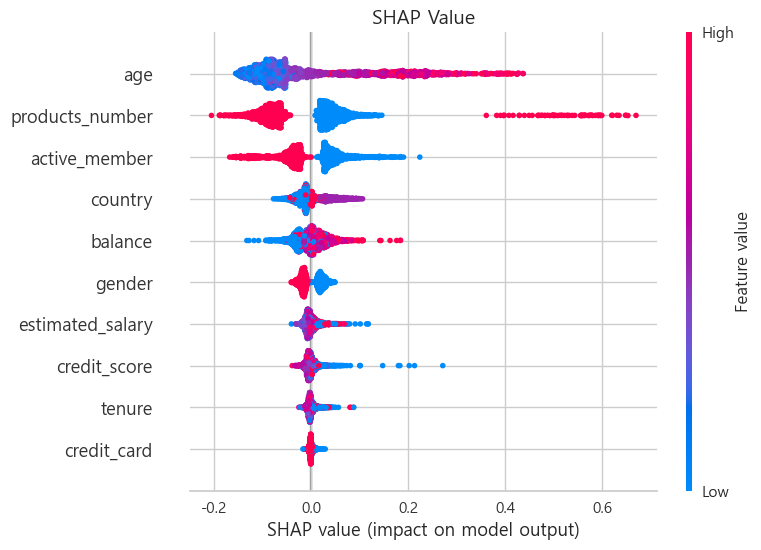


=== Stacking 앙상블 성능 ===
Stacking F1 Score: 0.5879


In [9]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

explainer = shap.TreeExplainer(rf) # RandomForest를 바탕으로 SHAP explainer 생성
shap_values = explainer.shap_values(X_valid) # X_valid를 바탕으로 SHAP value 계산

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list): # if문을 사용해서 shap_values가 리스트인지 아닌지 확인
    shap_values = shap_values[1] # 리스트라면 1번(이탈) 값을 shap_values로 설정
elif shap_values.ndim == 3: # 3차원 배열인지 확인
    shap_values = shap_values[:, :, 1] # 3차원 배열이라면 마지막 차원의 1번(이탈) 인덱스의 값을 가져 옴.
else:
    shap_values = shap_values # 둘 다 아니라면 그냥 사용

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot", # 점으로 표현
    show=False # 아직 안 보여줌
)
plt.title("SHAP Value", fontsize=14) # 그래프 제목
plt.show() # 그래프 출력

# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) # F1 스코어, accuracy_score 출력 = acc는 80정도, f1는 57 정도 나올 예정
# 최상위 모델들을 전방모델(Base)로, 선형모델을 후방모델(Meta)로 배치
est_model_list = [
    ('lgbm', lgbm),
    ('xgb', xgb),
    ('rf', rf)
] # 전방 모델을 뭘로 할지 설정

stack = StackingClassifier(
    estimators=est_model_list, # 전방 모델 리스트
    final_estimator=LogisticRegression(), # 후방 모델를 설정
    cv=5 # 교차검증을 5번 정도로 설정
) # Stacking 모델을 어떻게 할지 설정

stack.fit(X_train, y_train) # 학습
stack_pred = stack.predict(X_valid) # 예측값 확인

print("\n=== Stacking 앙상블 성능 ===") # 성능 출력
print(f"Stacking F1 Score: {f1_score(y_valid, stack_pred):.4f}") # f1_score 출력

# SHAP value 사후분석과 인사이트 제안
빨간색 점은 나이가 많은 고연령층을 뜻하고, 파란색 점은 나이가 적은 저연령층을 말합니다.

그리고 오른쪽인 (+) 방향으로 간다면 이탈을 높이는 요인이라는 뜻이고, (-)로 간다면 이탈을 막아주는 요인이라고 볼 수 있습니다.

위에 정보를 종합해 그래프를 분석하자면, 나이가 많을수록 이탈 할 확률이 높아지므로, 앞서 말한 가설과 일치하고 있습니다.

이와 같은 이탈을 방지하려면, 우선 청년층은 특별한 조치를 취하지 않아도 주거래 은행을 바꾸는 일이 거의 없기 때문에 괜찮지만 중장년층은 특히 조심해야 합니다.

중장년층 고객 유지를 위해 "은퇴 자금 우대 금리" 또는 건강을 타겟팅한 "건강 검진 제휴 혜택" 등 다양한 혜택과 상품을 활용해 고객 이탈을 방지하는 것이 좋은 제안이라고 생각합니다.

또한, 단순히 더 좋은 혜택이 있어서 이탈하는 게 아니라, 중장년층이 모바일 뱅킹 앱을 사용하기 어려워 하는 게 아닌지 확인하는 것도 좋은 방법일 수 있습니다.

최대한 글씨를 키우고, 메뉴를 단순화한 "중장년층 전용 모바일 앱" 이나 "중장년층 전용 모바일 기능"을 도입하는 것 또한 괜찮은 인사이트로 작용할 수 있습니다.

# validation score 출력
stacking 앙상블을 통해 성능을 출력한 결과, F1_score가 0.5895 정도 나오는 걸 확인하였습니다.
이는 F1_score가 57정도 나온다는 환경에서 나온 결과로 준수한 성능을 보인다고 해석할 수 있습니다.